# Segmentation model training with HAM10000 dataset

This notebook uses kagglehub's API to download the HAM10000 dataset from `kmader/skin-cancer-mnist-ham10000` and map it with segmentation masks from `tschandl/ham10000-lesion-segmentations`.

In [ ]:
# Install dependencies
from pathlib import Path
requirements_txt = Path("").absolute().parent.parent / "requirements.txt"
%pip install -r {requirements_txt}
# Note: You may need to restart the kernel after installing the dependencies.

In [2]:
# Define notebook imports
import os
from pathlib import Path

import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from kagglehub import KaggleDatasetAdapter
from torch.utils.data import Dataset
from torchvision.io import decode_image, ImageReadMode

### Load the HAM10000 dataset from Kaggle

In [3]:
# The dataset will be downloaded to src/datasets/
os.environ["KAGGLEHUB_CACHE"] = str(Path('').absolute().parent)

# Kaggle datasets
HAM10K_file_path = "HAM10000_metadata.csv"
HAM10K_dataset_kaggle_url = "kmader/skin-cancer-mnist-ham10000"

# Download the image files (~5.2 GB)
kagglehub.dataset_download(HAM10K_dataset_kaggle_url, force_download=False)

HAM10K_dataset_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    HAM10K_dataset_kaggle_url,
    HAM10K_file_path
)

print("\nFirst 5 items of dataset")
print(HAM10K_dataset_df.head())

print("\nColumn datatypes")
print(HAM10K_dataset_df.dtypes)

print(HAM10K_dataset_df.describe())


First 5 items of dataset
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear

Column datatypes
lesion_id        object
image_id         object
dx               object
dx_type          object
age             float64
sex              object
localization     object
dtype: object
               age
count  9958.000000
mean     51.863828
std      16.968614
min       0.000000
25%      40.000000
50%      50.000000
75%      65.000000
max      85.000000


### Clean the dataset by removing null values

In [4]:
print("Null values in the dataset:")
print(HAM10K_dataset_df.isnull().sum())

#Replace null values with the mean age
mean_age = round(HAM10K_dataset_df['age'].mean())
HAM10K_dataset_df.loc[:, 'age'] = HAM10K_dataset_df['age'].fillna(mean_age)

print(f"\n\nNull values in the dataset after replacing null age values with the mean ({mean_age}):")
print(HAM10K_dataset_df.isnull().sum())


Null values in the dataset:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


Null values in the dataset after replacing null age values with the mean (52):
lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64


### Sort the dataframe by ISIC Image ID

In [5]:
sorted_HAM_dataset = HAM10K_dataset_df.sort_values(
    by="image_id", 
    key=lambda isic_id: isic_id.str.lstrip("ISIC_").astype(int)
)

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")  # Use GPU
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")  # Fallback to CPU
    print("CUDA not available, using CPU.")

### Map the HAM10000 `dx` column to the full lesion type name and load the segmentation masks

In [7]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
sorted_HAM_dataset.loc[:, 'dx'] = sorted_HAM_dataset['dx'].map(lesion_type_dict)

HAM10K_segmentations_kaggle_url = "tschandl/ham10000-lesion-segmentations"

# Load the segmentation data from tschandl's dataset (~10 MB)
HAM10K_segmentations_dataset_path = kagglehub.dataset_download(HAM10K_segmentations_kaggle_url, force_download=False)

In [8]:
class LesionDataset(Dataset):
    def __init__(self, annotations, transform=None) -> None:
        super().__init__()
        self.img_labels = annotations
        self.mask_dir = Path(os.environ["KAGGLEHUB_CACHE"]).absolute() / "datasets" / "tschandl" / "ham10000-lesion-segmentations" / "versions" / "1" / "HAM10000_segmentations_lesion_tschandl"
        self.mask_names = list(self.mask_dir.glob("ISIC_*_segmentation.png"))
        self.img_dirs = [
            Path(os.environ["KAGGLEHUB_CACHE"]).absolute() / "datasets" / "kmader" / "skin-cancer-mnist-ham10000" / "versions" / "2" / "HAM10000_images_part_1",
            Path(os.environ["KAGGLEHUB_CACHE"]).absolute() / "datasets" / "kmader" / "skin-cancer-mnist-ham10000" / "versions" / "2" / "HAM10000_images_part_2",
        ]
        self.transform = transform
        assert len(self.mask_names) == len(self.img_labels), "Number of masks and labels do not match"

    def __len__(self) -> int:
        return len(self.mask_names)

    def __getitem__(self, index) -> tuple[pd.Series, torch.Tensor, torch.Tensor]:
        label = self.img_labels.iloc[index]

        for img_dir in self.img_dirs:
            if (img_dir / f"{label['image_id']}.jpg").exists():
                break
        else:
            raise FileNotFoundError(f"Image file not found for image_id: {label['image_id']}")

        img_path = img_dir / f"{label['image_id']}.jpg"
        img = decode_image(img_path, mode=ImageReadMode.RGB)

        mask_path = self.mask_dir / f"{label['image_id']}_segmentation.png"
        mask = decode_image(mask_path, mode=ImageReadMode.GRAY)
        binary_mask = (mask > 0.5).float()
        
        # Convert to numpy for feature extraction
        np_img = img.permute(1, 2, 0).numpy()
        np_mask = binary_mask.squeeze(0).numpy()

        # Extract ABCD features
        abcd_features = self.extract_abcd_features(np_img, np_mask)
    
        # Apply the mask and normalize the image to [0, 1] range (0-255 to 0-1)
        img = (img * binary_mask) / 255.0

        return label, img, abcd_features

    def extract_a(self, contour, mask):
        # A: Asymmetry
        moments = cv2.moments(contour)
        if moments["m00"] != 0:
            centroid_x = int(moments["m10"] / moments["m00"])
            centroid_y = int(moments["m01"] / moments["m00"])
        else:
            centroid_x, centroid_y = 0, 0
        
        # Divide the mask into quadrants through the centroid
        top_half = mask[:centroid_y, :]
        bottom_half = mask[centroid_y:, :]
        left_half = mask[:, :centroid_x]
        right_half = mask[:, centroid_x:]
            
        # Reshape halves to have the same size for comparison
        # Vertical axis comparison
        if top_half.shape[0] > 0 and bottom_half.shape[0] > 0:
            # Flip bottom half
            bottom_half_flipped = cv2.flip(bottom_half, 0)
            # Resize to match top half
            min_height = min(top_half.shape[0], bottom_half_flipped.shape[0])
            min_width = min(top_half.shape[1], bottom_half_flipped.shape[1])
            top_crop = top_half[-min_height:, :min_width]
            bottom_crop = bottom_half_flipped[-min_height:, :min_width]
            # Calculate difference
            vertical_diff = np.sum(np.abs(top_crop - bottom_crop)) / (np.sum(top_crop) + np.sum(bottom_crop) + 1e-8)
        else:
            vertical_diff = 0
            
        # Horizontal axis comparison
        if left_half.shape[1] > 0 and right_half.shape[1] > 0:
            # Flip right half
            right_half_flipped = cv2.flip(right_half, 1)
            # Resize to match left half
            min_height = min(left_half.shape[0], right_half_flipped.shape[0])
            min_width = min(left_half.shape[1], right_half_flipped.shape[1])
            left_crop = left_half[:min_height, -min_width:]
            right_crop = right_half_flipped[:min_height, -min_width:]
            # Calculate difference
            horizontal_diff = np.sum(np.abs(left_crop - right_crop)) / (np.sum(left_crop) + np.sum(right_crop) + 1e-8)
        else:
            horizontal_diff = 0
            
        # ABCD score calculation: 
        # Use a threshold to determine if asymmetry is present in each axis
        threshold = 0.3  # Arbitrary threshold for asymmetry
        vertical_asymmetry = vertical_diff > threshold
        horizontal_asymmetry = horizontal_diff > threshold
        
        # Score: 0 if no asymmetry, 1 if one axis, 2 if both axes
        asymmetry_score = int(vertical_asymmetry) + int(horizontal_asymmetry)
        
        # TDS contribution = score * 1.3
        tds_contribution_a = asymmetry_score * 1.3
        
        # Store both raw measurements and the score
        asymm_features = [vertical_diff, horizontal_diff, asymmetry_score, tds_contribution_a]

        print(f"Vertical asymmetry: {vertical_diff}, Horizontal asymmetry: {horizontal_diff}, Asymmetry score: {asymmetry_score}, TDS contribution A: {tds_contribution_a}")

        return asymm_features

    def extract_abcd_features(self, image, mask):
        # Find contours of the lesion
        contours, _ = cv2.findContours((mask * 255).astype(np.uint8), 
                                       cv2.RETR_EXTERNAL, 
                                       cv2.CHAIN_APPROX_SIMPLE)
        
        if not contours:
            # Return default values if no contour found
            return torch.zeros(12)
        contour = max(contours, key=cv2.contourArea)

        features = []

        # A: Asymmetry
        a_features = self.extract_a(contour, mask)
        features.extend(a_features)

        # TODO:
        # B: Border irregularity
        # C: Color variation
        # D: Diameter

        return torch.tensor(features, dtype=torch.float32)


lesion_dataset = LesionDataset(sorted_HAM_dataset)

Vertical asymmetry: 0.09390701353549957, Horizontal asymmetry: 0.12128710001707077, Asymmetry score: 0, TDS contribution A: 0.0
Displaying the image for:
lesion_id            HAM_0000550
image_id            ISIC_0024306
dx              Melanocytic nevi
dx_type                follow_up
age                         45.0
sex                         male
localization               trunk
Name: 4349, dtype: object


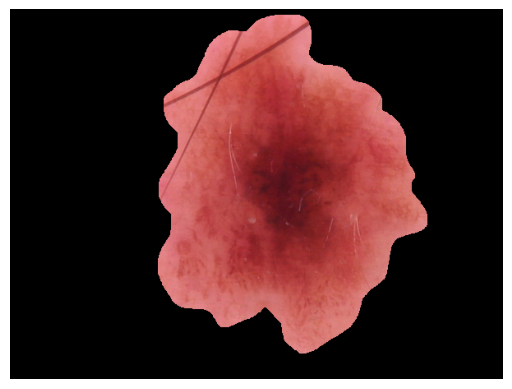

In [9]:
# Verify the dataset loads correctly
# for i in range(len(lesion_dataset)):
#     lesion_dataset[i]

# Display the first image as demo
label, lesion_img, _ = lesion_dataset[0]
print(f"Displaying the image for:\n{label}")
plt.imshow(lesion_img.permute(1, 2, 0))  # permute dimensions from [C, H, W] to [H, W, C]
plt.axis('off')
plt.show()